In [224]:
import numpy as np
import os
from micado_misthic import misthic_func
from configobj import ConfigObj
from micado_misthic.utils.obsparams import * 
from astropy.table import Table
import matplotlib as mpl
import pandas as pd

### Main directory of the repos
repository_dir              = 'C:/Users/Red Slottje/Documents/micado_misthic'

### directory with flux & transmission data for MICADO
flux_dir                    = repository_dir + '/flux_data/'

### directories with the coronagraphic simulated images
all_coro_sim_dir_prefix     = 'D:/FROM_RED/coro_sims/'

### directories to record the processed data
record_dir_prefix     = 'D:/FROM_RED/coro_adi_new/ADI/'


###-- Observation params
coronagraph     = 'CLC1' # 'CLC0' or 'CLC1'
quartile        = 'Q1'#['Q1', 'Q4', 'MED']
keyword_NCPA    = 'NoNCPA' 
lbd             = 1.582 # Choose filter
p_dist_mas      = 13.052
duree = [60.0]
pixscale_in_mas = 1.5 # 1.5 or 4 mas

coro_sim_dir         = all_coro_sim_dir_prefix + f'{coronagraph}_{quartile}_NoNCPA/lambda={lbd:5.3f}/p_dist_mas={p_dist_mas}/TURBU_ABERR/duree={duree[0]}min/'
#coro_resized_dir    =  record_dir_prefix + f'D:\FROM_RED\resized_fft_coro\CLC1_Q1_noNCPA\lbd={lbd}_pxscale={pixscale_in_mas}'
coro_resized_dir = record_dir_prefix
planet_resized_dir = record_dir_prefix+'PLANET/'

### path to the configspec file (same as the misthic_func.py module)
configspec_file   = os.path.dirname(misthic_func.__file__)+'/misthic_configspec.ini'

### Read infos from the .ini file of the directory to process
ini_file = [f for f in os.listdir(coro_sim_dir) if f.endswith('.ini')][0]
config  = ConfigObj(coro_sim_dir+ini_file, configspec=configspec_file)
detector_sampling = np.float32(config['detectorconfig']['detector_sampling']) ## Sampling for initial simulation
frame_exp_time  = np.float32(config['simuconfig']['delta_t']) ## exposure time per frame in seconds 


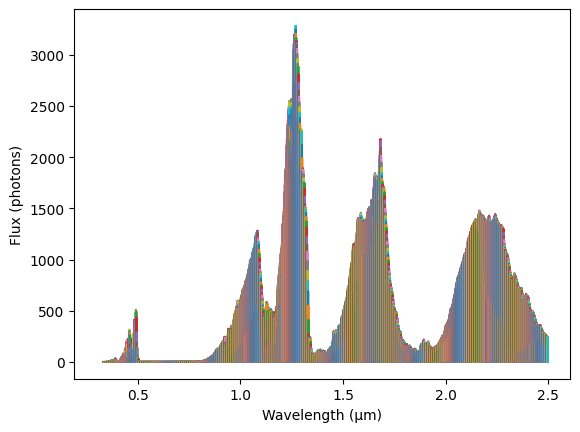

In [195]:
spec_dir = 'C:/Users/Red Slottje/Documents/Misthic_inputs/R500_cloudless_2025/'
metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
logg = [3.0, 3.5, 4.0, 4.5, 5.0]
CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
temp = np.arange(200, 1000, 50)
r_pl    = 1
dist_pc = 39.4
airmass = 1.
telescope_pupil_file        = f'D:/FROM_NELLIE/INPUT_fromNellie/PUPIL/Pupil_ELT_v03.fits'
planet_flux_list = []
spec_wave_list = []
planet_photon_flux_list = []

telescope_surface = get_aperture_surface(telescope_pupil_file)
#_, star_flux = get_star_spectrum(flux_dir, star_mag, lbd[0])
for i in range(len(temp)):
    for j in range(len(logg)):
        for k in range(len(metallicity)):
            for l in range(len(CO)):
                if spec_dir+f'spectra_YGP_{temp[i]}K_logg{logg[j]}_met{metallicity[k]}_CO{CO[l]}.dat' != 0 :
                    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[i], logg[j], metallicity[k], CO[l], dist_pc, r_pl, flux_dir=flux_dir)
                    planet_flux_list.append(planet_flux)
                    spec_wave_list.append(spec_wave)
                else : 
                    continue

#C:/Users/Red Slottje/Documents/Misthic_inputs/R500_cloudless_2025/spectra_YGP_450K_logg4.0_met1.00_CO0.75.dat not found. (CO0.75 missing)    

#some of them are missing ; must be in the missing gridpoints grid


# met{metallicity:.2f}_CO{CO:3.2f}
plt.plot(spec_wave_list,planet_flux_list)
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux (photons)')
plt.show()

# photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, star_flux, f'{lbd[0]:5.3f}', 
#                                                                      frame_exp_time, telescope_surface, 
#                                                                      airmass=airmass, pixel_scale=pixscale_in_mas)


In [196]:
# writing the parameters to a fits file 

# metallicity = np.array([0.32, 1.00, 3.16, 10.00, 31.62, 100.00])
# temp = np.arange(200, 2000, 50)
# logg = np.array([3.0, 3.5, 4.0, 4.5, 5.0])
# CO =  np.array([0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70])
# lbd = np.array([1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145])

metacube = { 'metallicity' : np.array([0.32, 1.00, 3.16, 10.00, 31.62, 100.00]), 
                'temp' : np.arange(200, 2000, 50),
                'logg' : np.array([3.0, 3.5, 4.0, 4.5, 5.0]),
                'CO' :  np.array([0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]),
                'lbd' : np.array([1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145])}
# col1 = fits.Column(name= 'Metallicity', format = 'E', array = metallicity)
# col2 = fits.Column(name = 'Temperature', format = 'E', array = temp)
# col3 = fits.Column(name = 'logg', format = 'E', array = logg)
# col4 = fits.Column(name = 'CO', format = 'E',  array = CO)
# col5 = fits.Column(name = 'Wavelength', format = 'E', array = lbd)

# fits_header = fits.Header()
# fits_header['INFO'] = "Planet physical parameters : contains metallicity, temperature, logg, CO and wavelength filters for MICADO. Created to simplify parameter handling in simulations."
# primary_HDU = fits.PrimaryHDU(header = fits_header)
# metallicity_HDU = fits.BinTableHDU.from_columns(fits.ColDefs([col1]))
# temperature_HDU = fits.TableHDU.from_columns(fits.ColDefs([col2]))
# logg_HDU = fits.TableHDU.from_columns(fits.ColDefs([col3]))
# CO_HDU = fits.TableHDU.from_columns(fits.ColDefs([col4]))
# wavelength_HDU = fits.TableHDU.from_columns(fits.ColDefs([col5]))

#hdu_list = fits.HDUList([primary_HDU, metallicity_HDU, temperature_HDU, logg_HDU, CO_HDU, wavelength_HDU])


#fits.writeto('physical_planet_parameters_storage.fits', metacube)

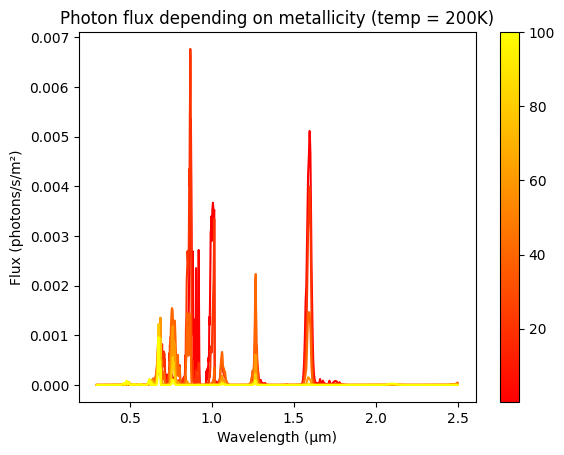

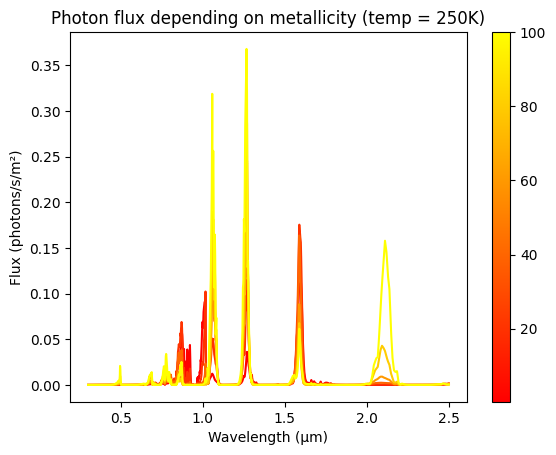

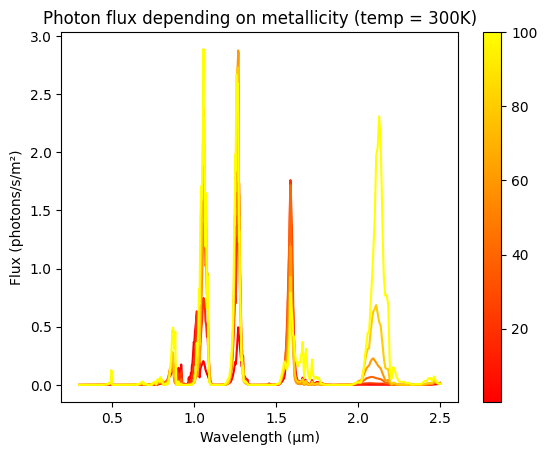

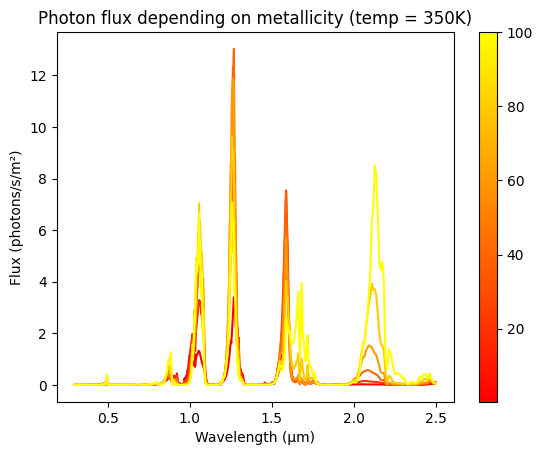

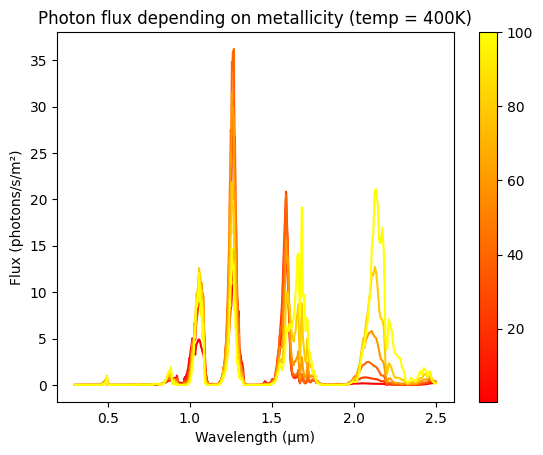

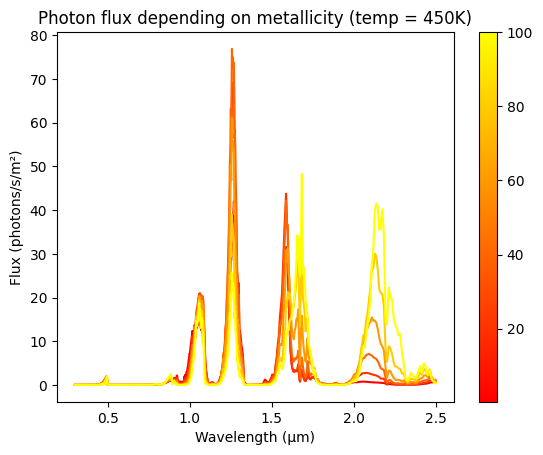

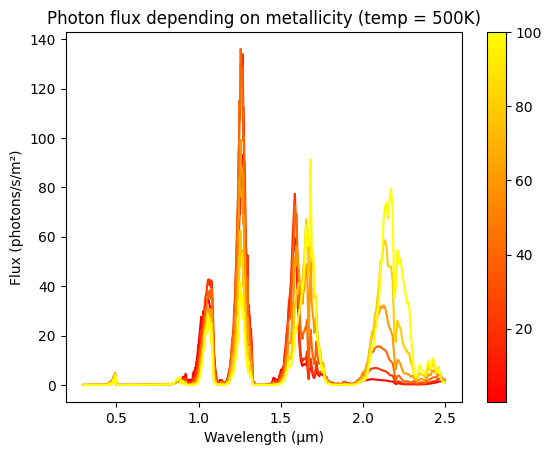

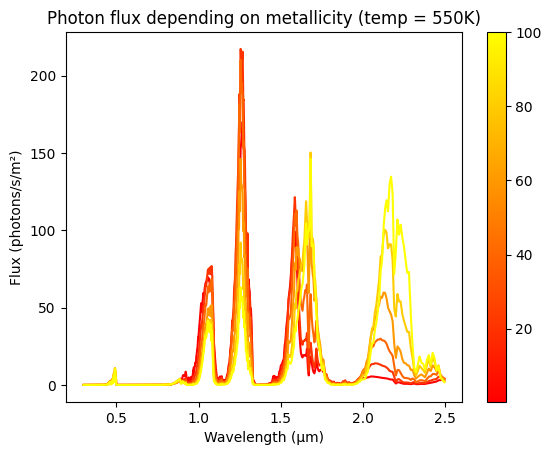

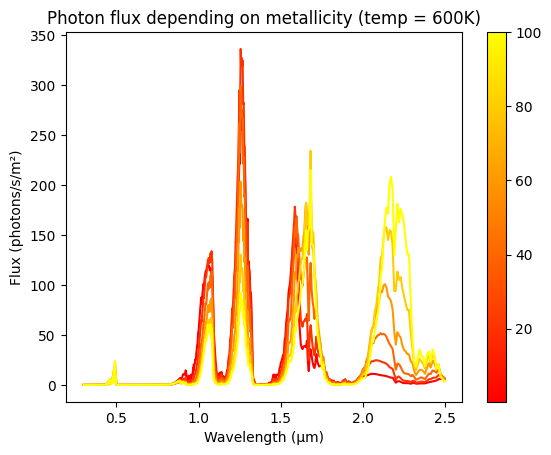

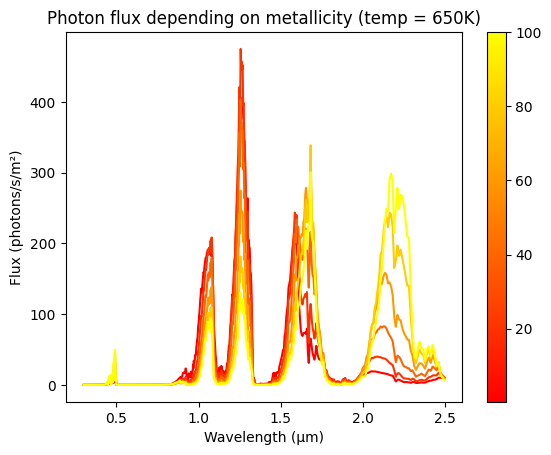

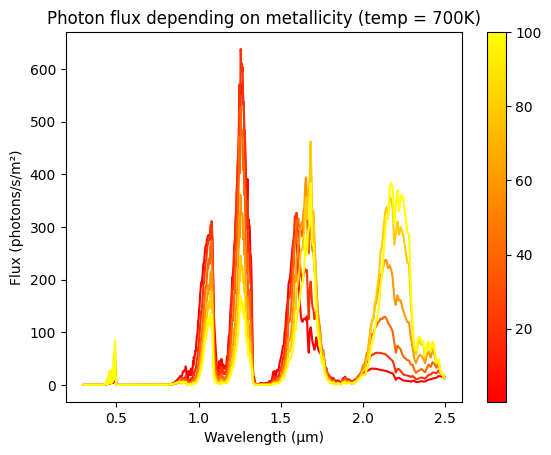

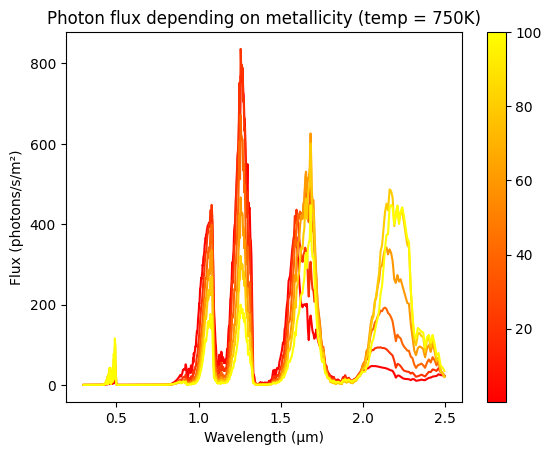

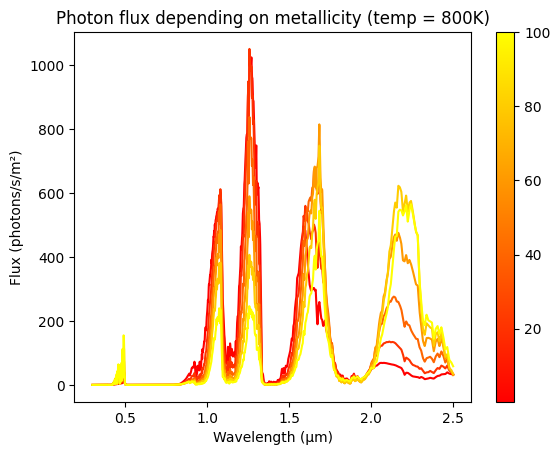

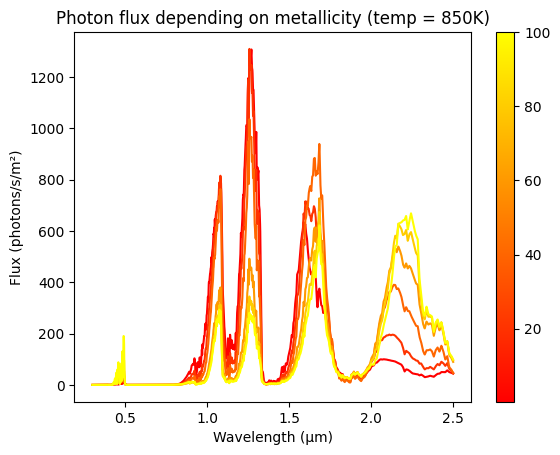

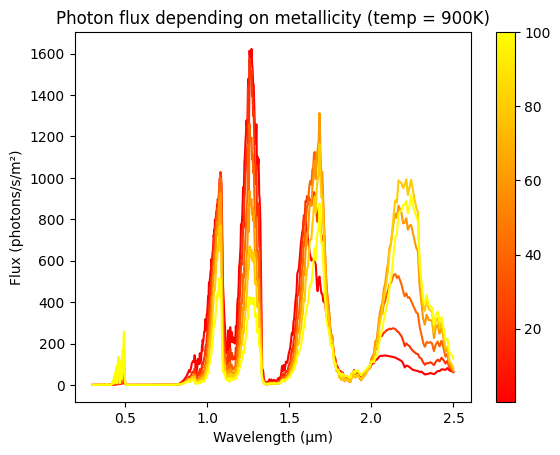

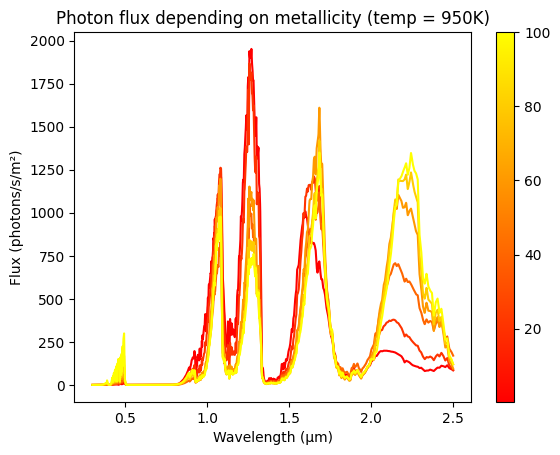

In [ ]:
# metallicity with fix temp

metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
temp = np.arange(200, 1000, 50)
logg = 3.5
CO = 0.25

n = len(metallicity)
colors = plt.cm.autumn(np.linspace(0,1,n))

planet_photon_flux_list = []

# setting up the colorbar
c = np.array(metallicity)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

for j in range(len(temp)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(metallicity)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[j], logg, metallicity[k], CO, dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color=colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Photon flux depending on metallicity (temp = {temp[j]}K)')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons/s/m²)')
    plt.show()


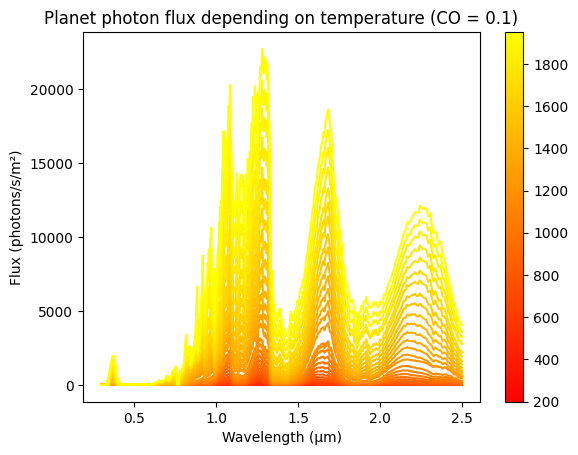

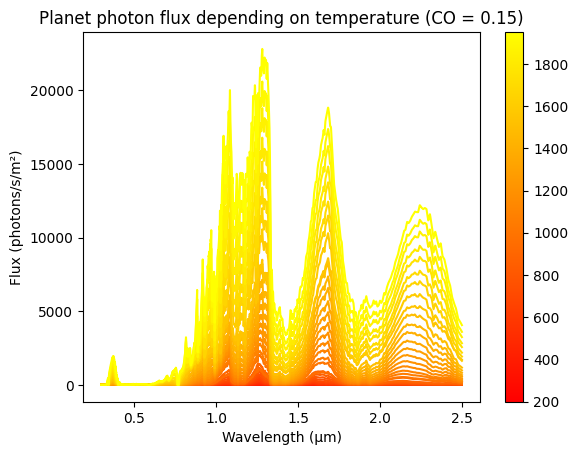

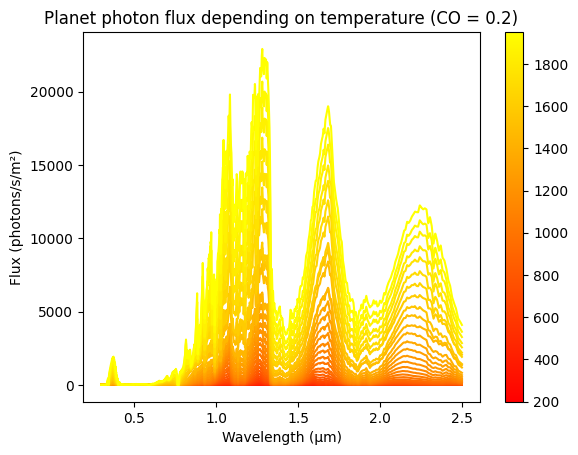

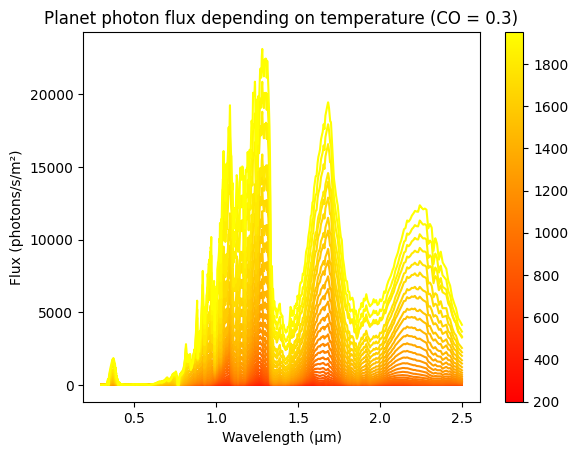

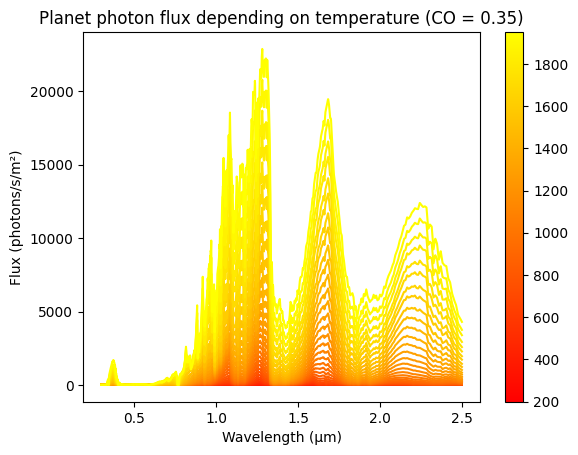

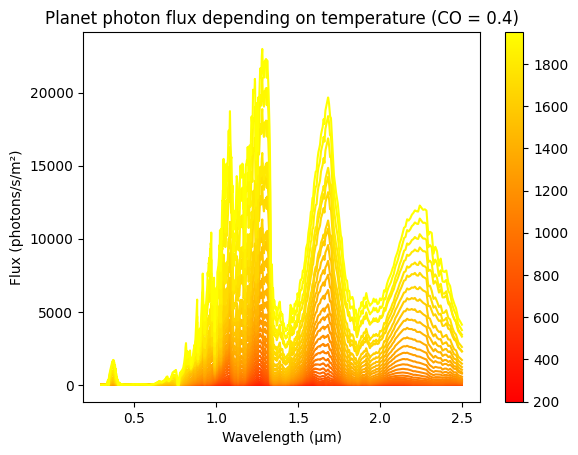

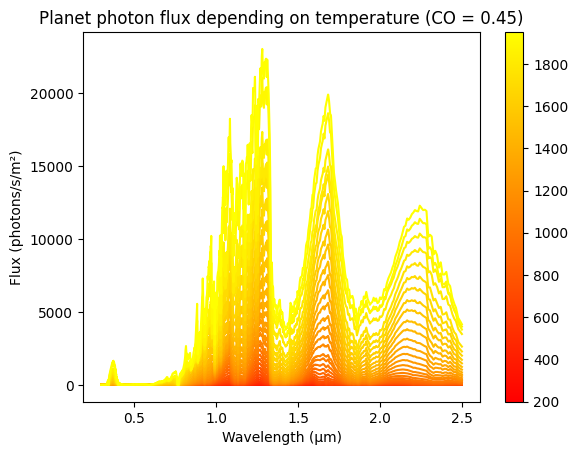

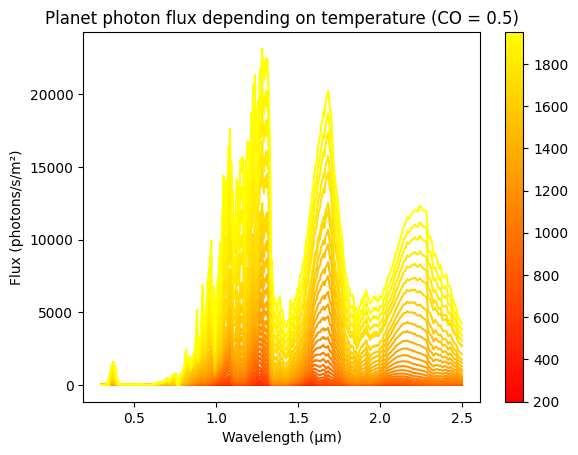

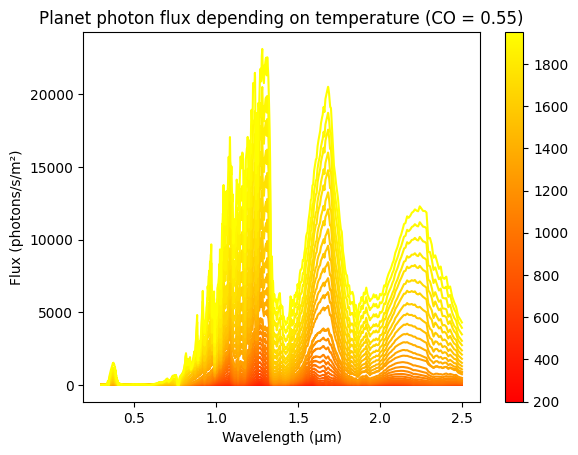

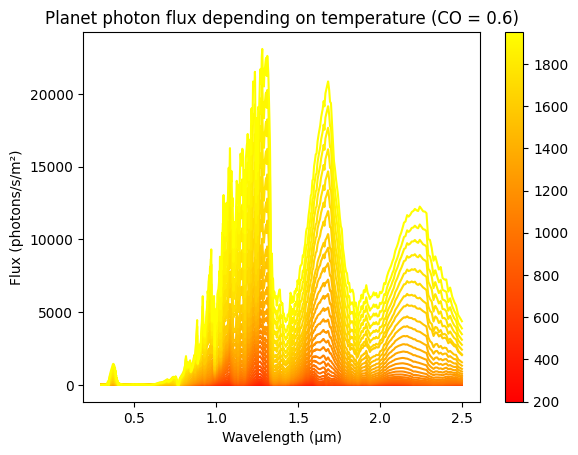

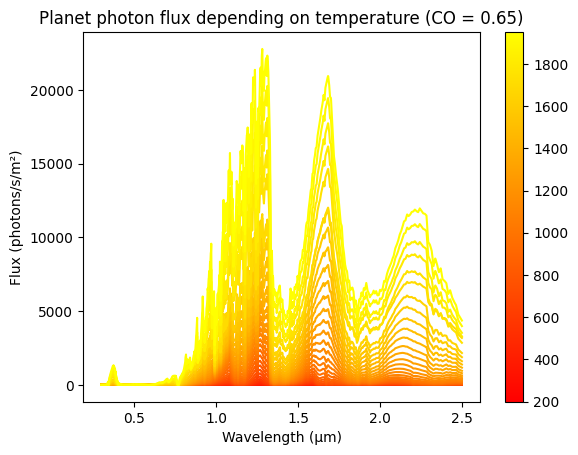

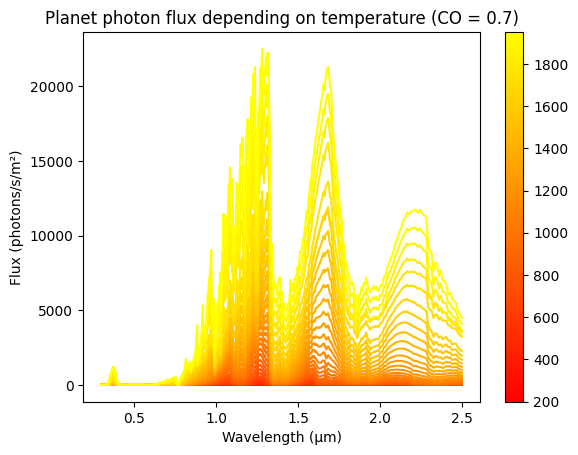

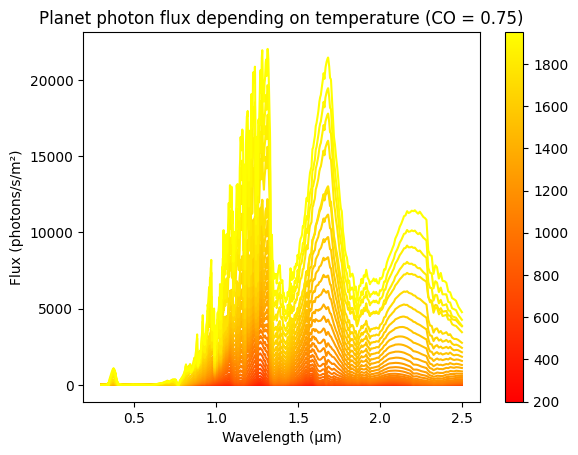

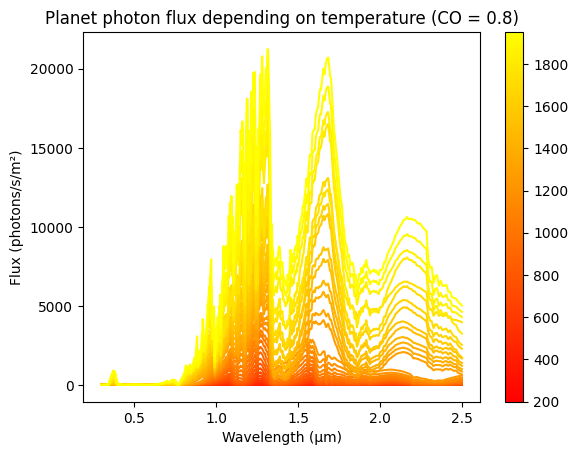

In [215]:
#temp with fix CO
metallicity = 1.0
temp = np.arange(200, 2000, 50)
logg = 3.5
CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

n = len(temp)
colors = plt.cm.autumn(np.linspace(0,1,n))

c = temp
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

for j in range(len(CO)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(temp)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[k], logg, metallicity, CO[j], dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color = colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Planet photon flux depending on temperature (CO = {CO[j]})')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons/s/m²)')
    plt.show()

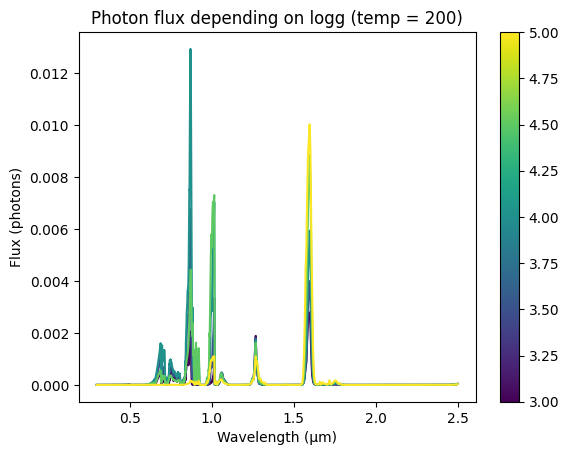

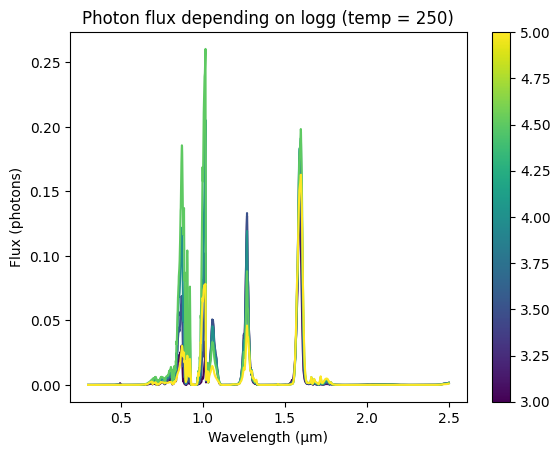

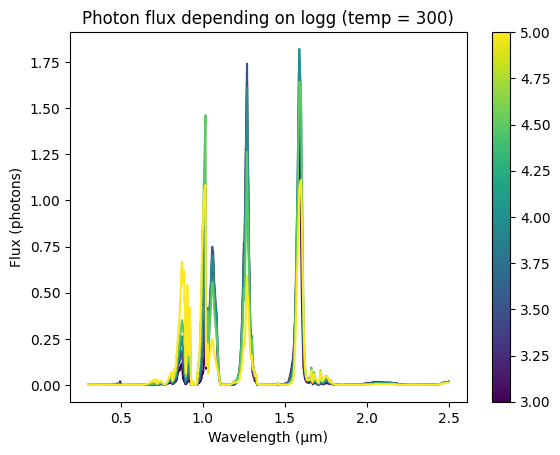

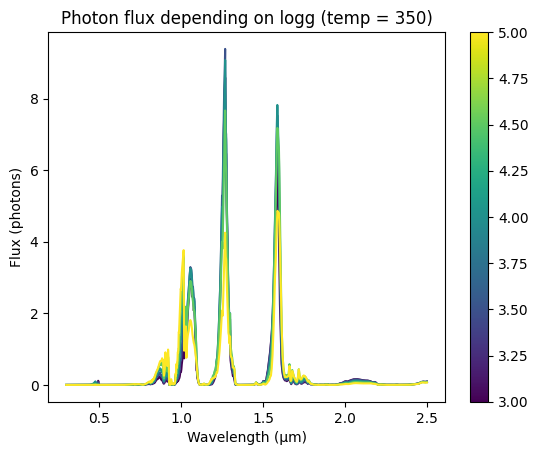

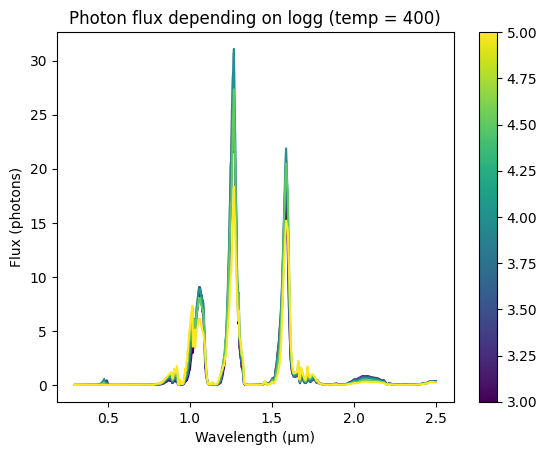

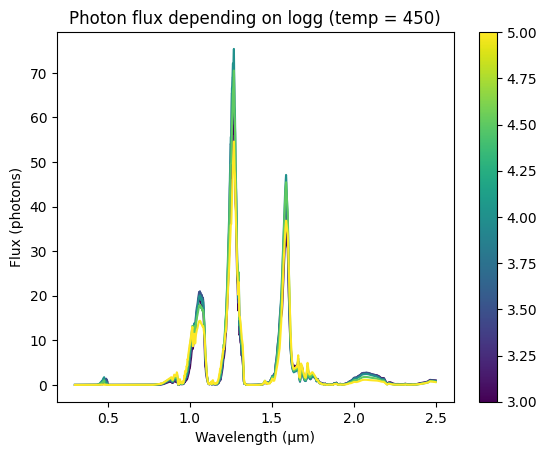

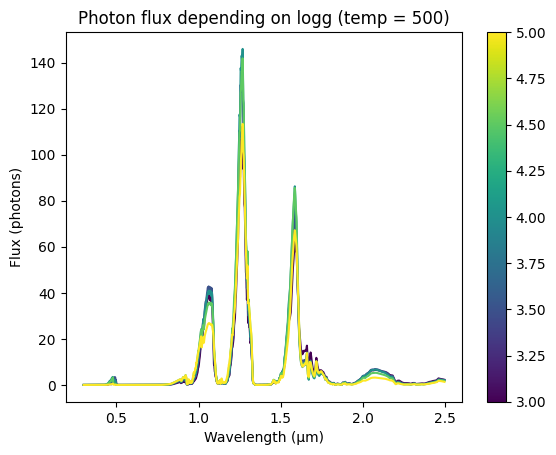

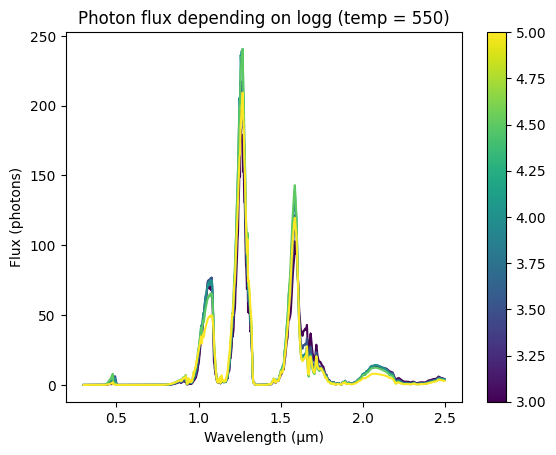

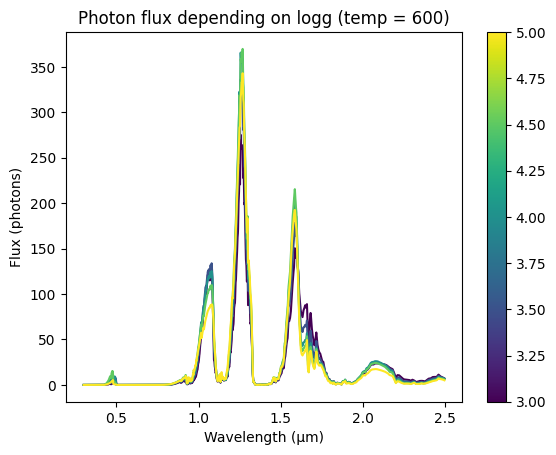

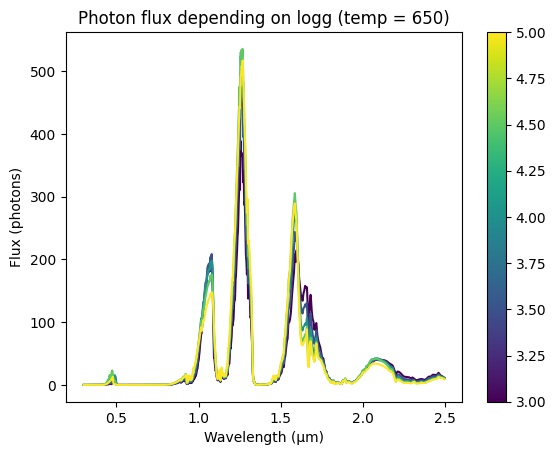

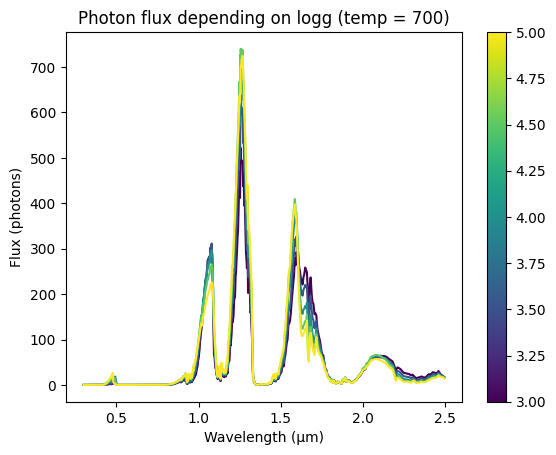

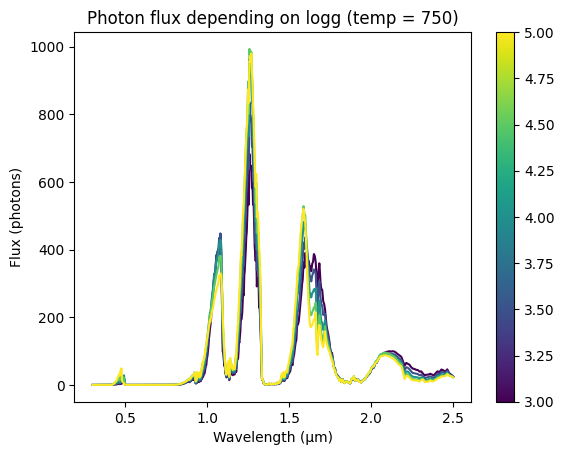

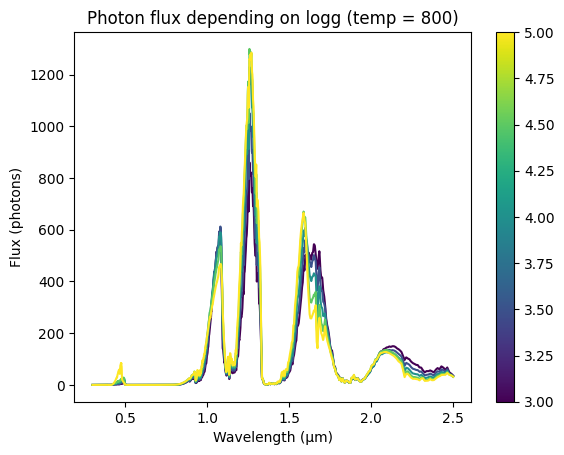

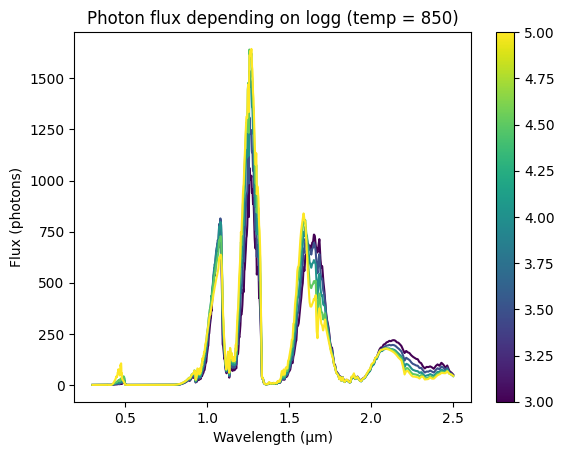

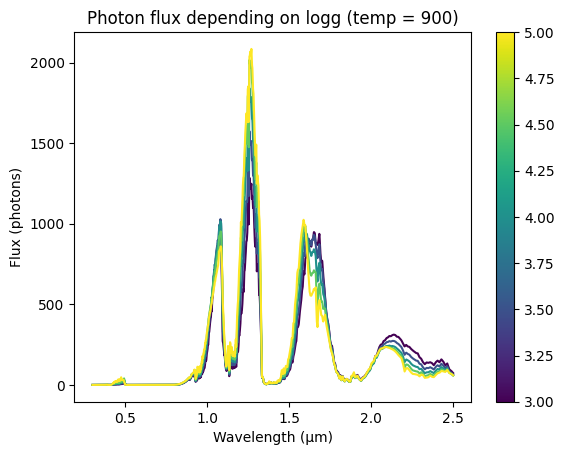

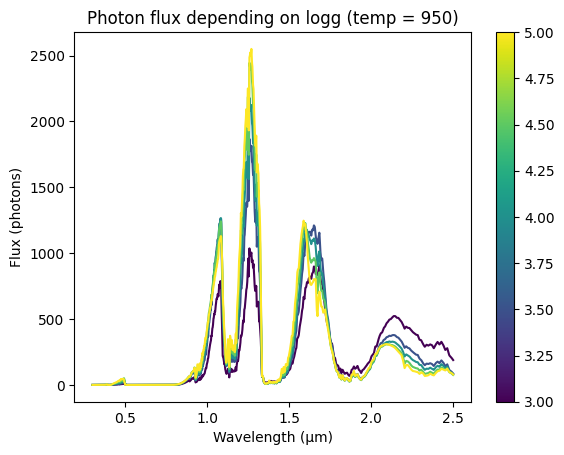

In [217]:
# logg with fix temp
metallicity = 1.00
temp = np.arange(200, 1000, 50)
logg = [3.0, 3.5, 4.0, 4.5, 5.0]
CO = 0.25

n = len(logg)
colors = plt.cm.viridis(np.linspace(0,1,n))

c = np.array(logg)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])

for j in range(len(temp)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(logg)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[j], logg[k], metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color = colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Photon flux depending on logg (temp = {temp[j]})')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons)')
    plt.show()

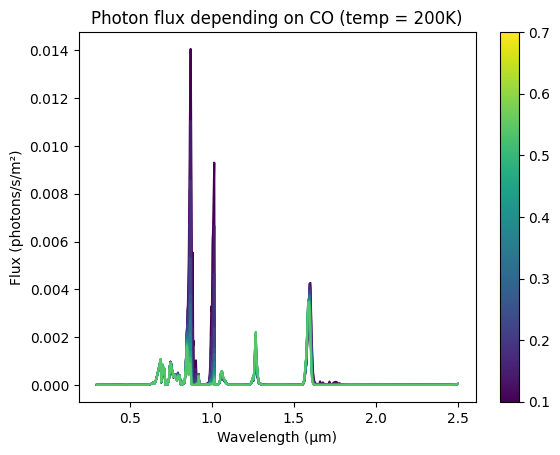

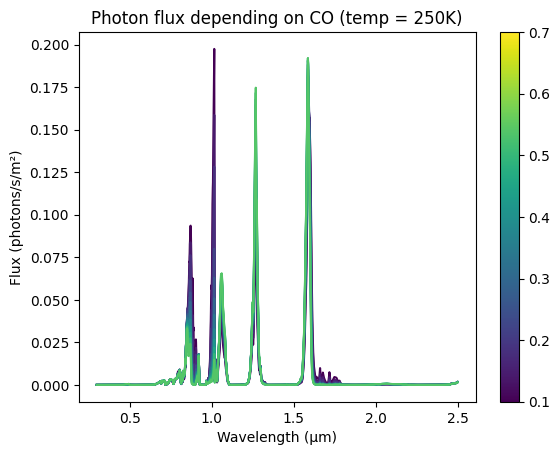

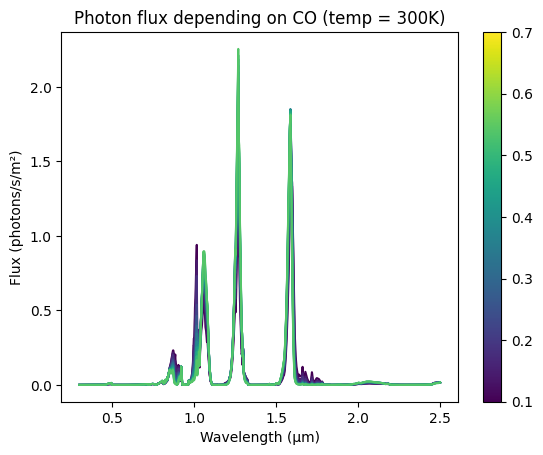

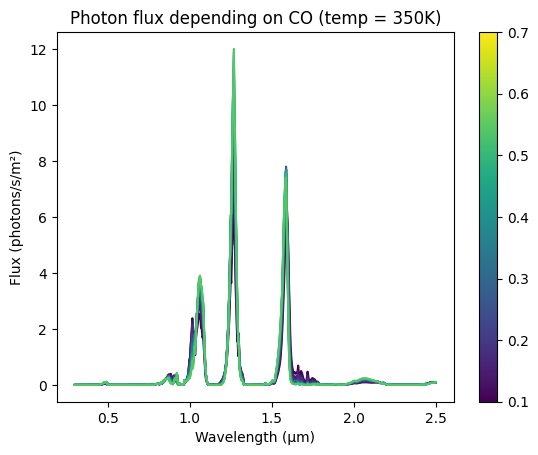

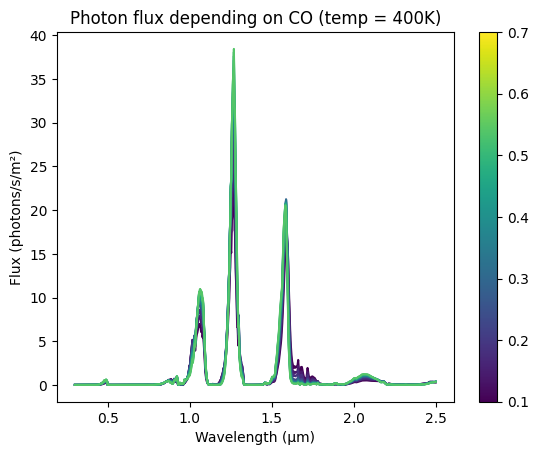

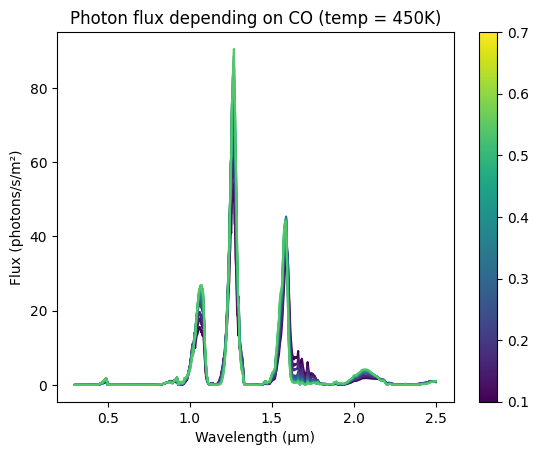

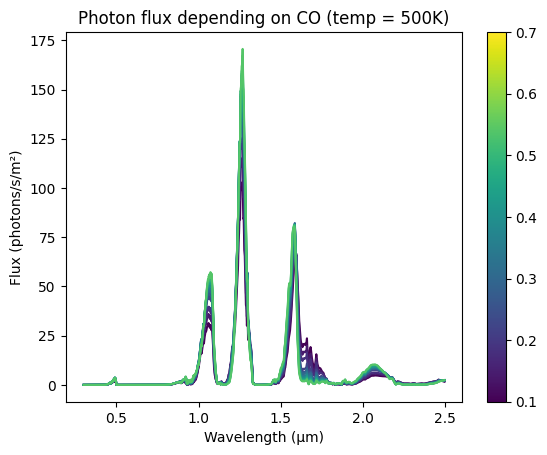

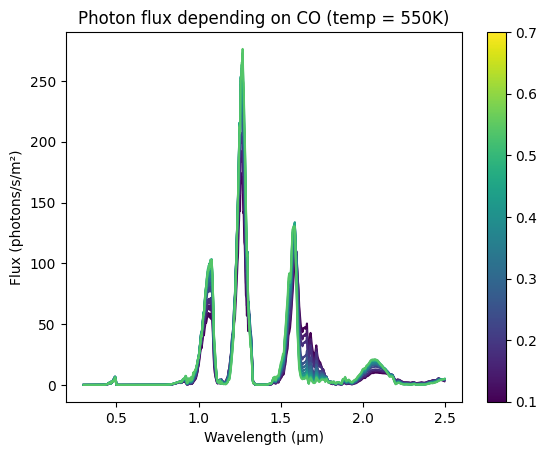

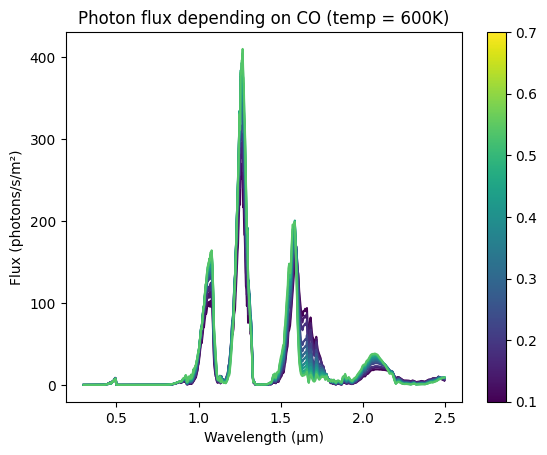

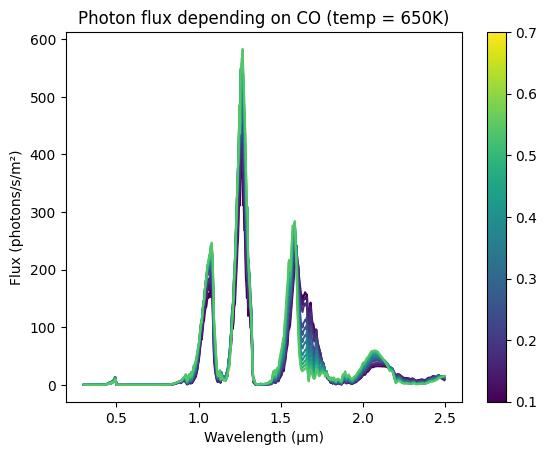

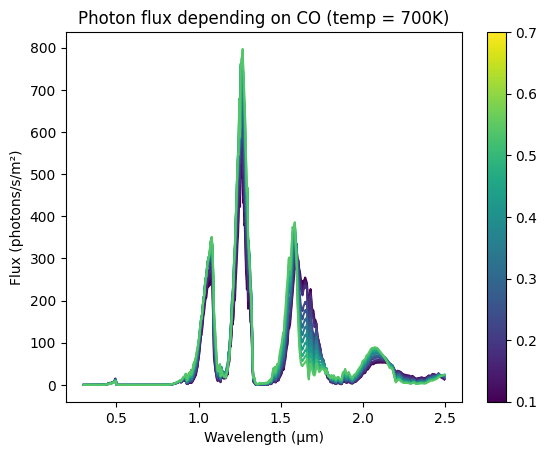

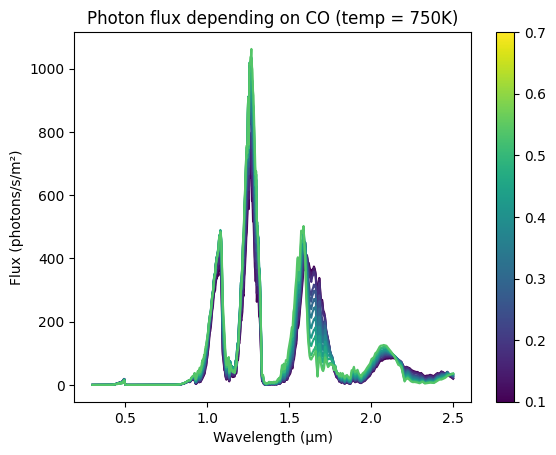

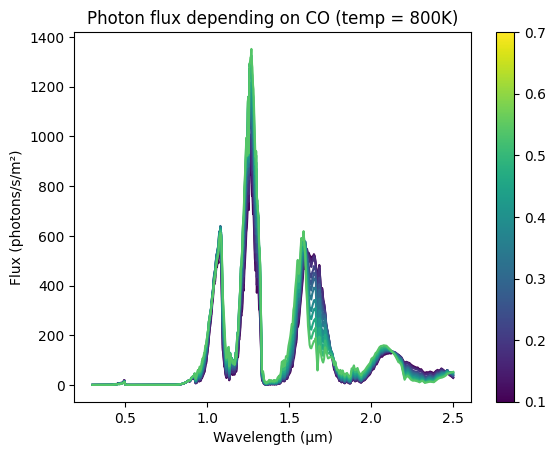

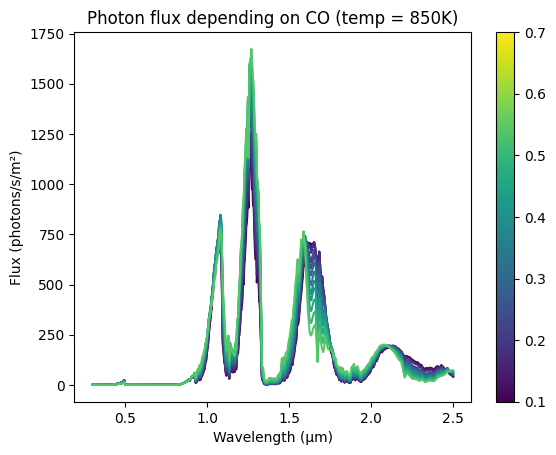

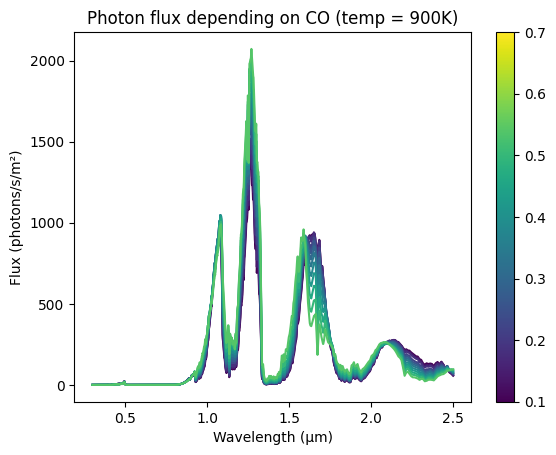

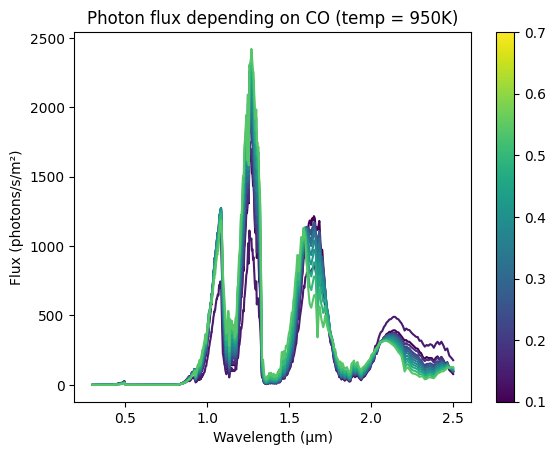

In [219]:
# CO with fix temp
metallicity = 1.00
temp = np.arange(200, 1000, 50)
logg = 3.5
CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

n = len(temp)
colors = plt.cm.viridis(np.linspace(0,1,n))

c = np.array(CO)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])

for j in range(len(temp)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(CO)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[j], logg, metallicity, CO[k], dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color = colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Photon flux depending on CO (temp = {temp[j]}K)')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons/s/m²)')
    plt.show()

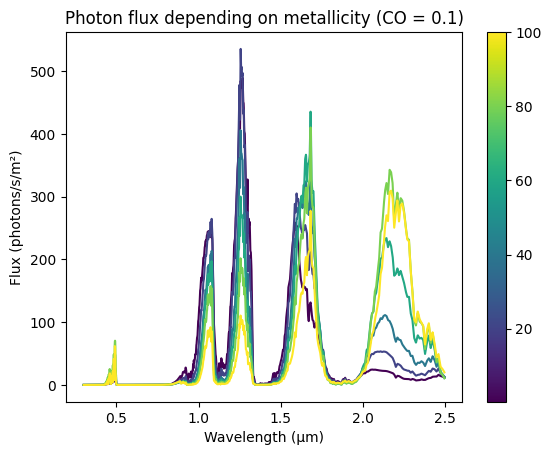

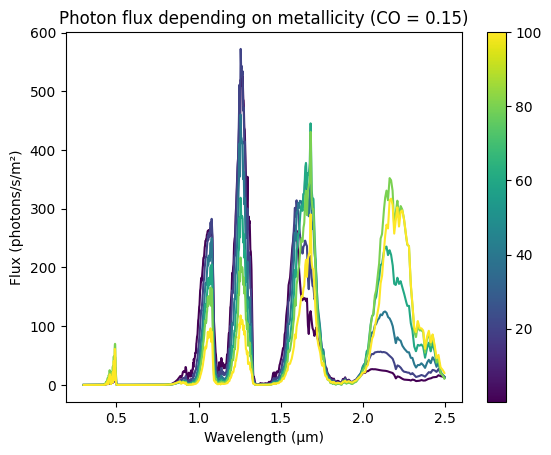

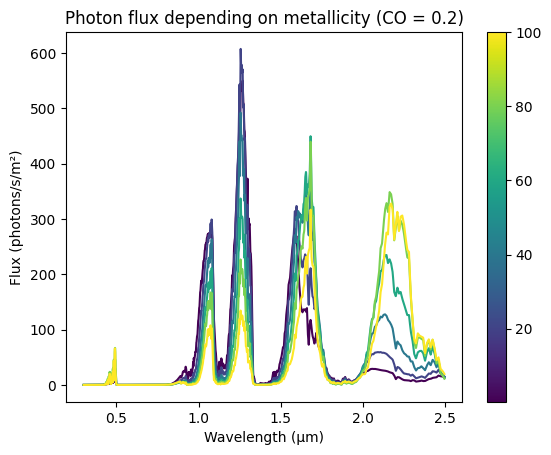

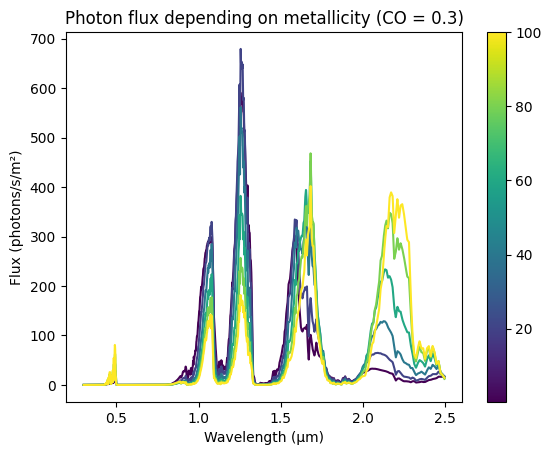

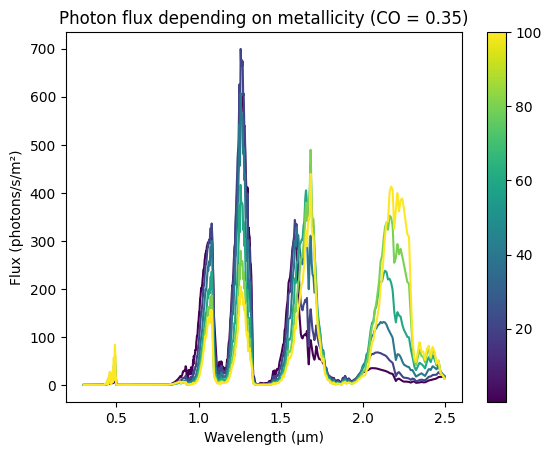

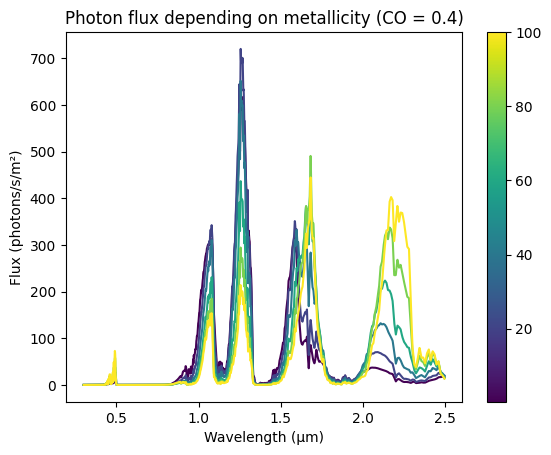

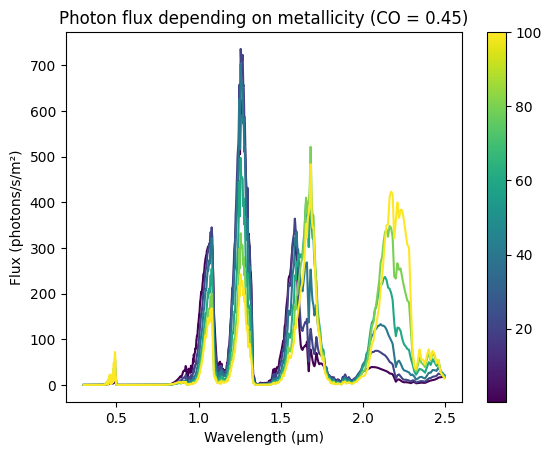

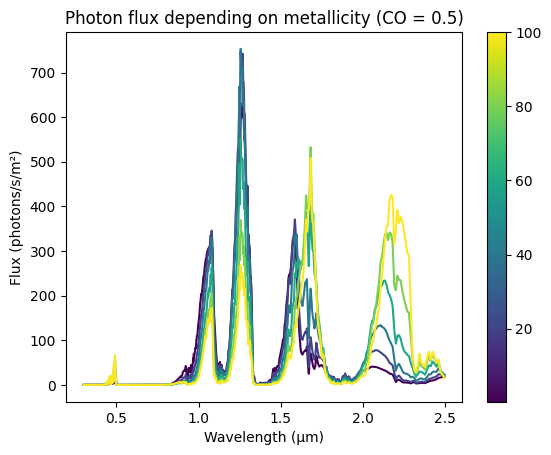

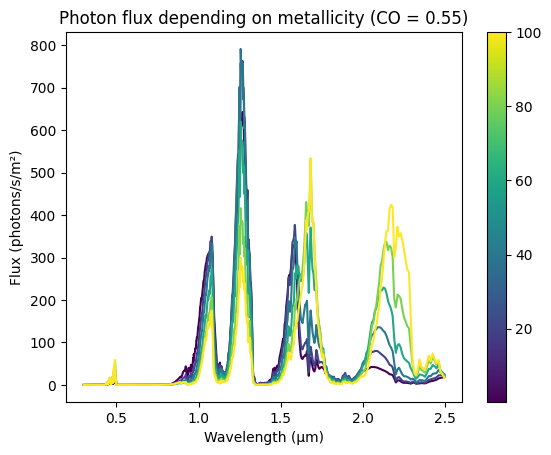

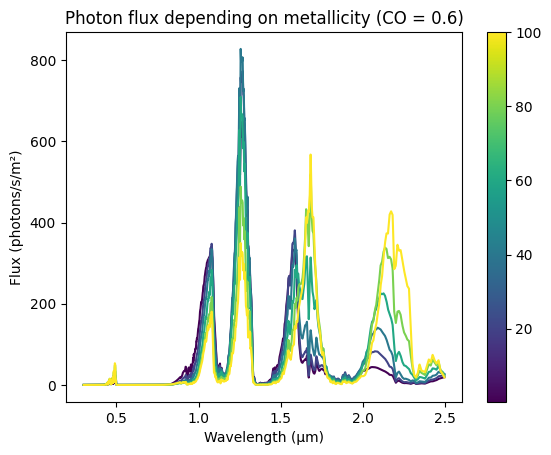

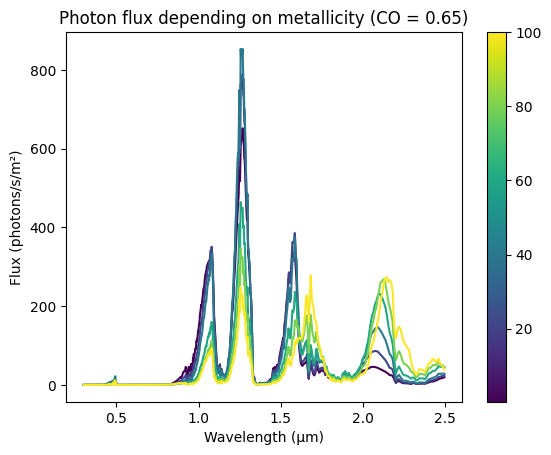

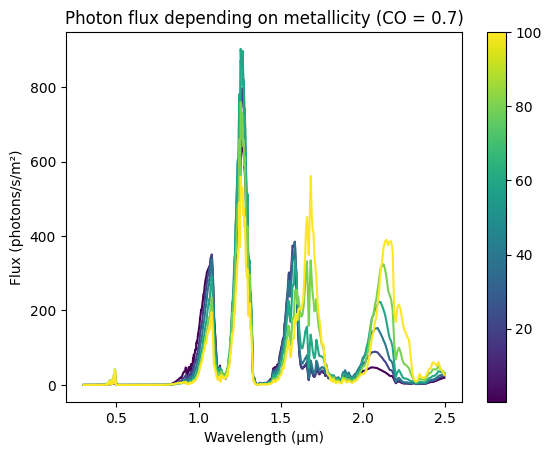

In [220]:
#metallicity with fixed CO
metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
temp = 700
logg = 3.5
CO = [0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

c = np.array(metallicity)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])

n = len(metallicity)
colors = plt.cm.viridis(np.linspace(0,1,n))
for j in range(len(CO)):
    fig, ax = plt.subplots(dpi=100)
    for k in range(len(metallicity)):
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity[k], CO[j], dist_pc, r_pl, flux_dir=flux_dir)
        plt.plot(spec_wave,planet_flux, color = colors[k])

    plt.colorbar(cmap, ax = ax)
    plt.title(f'Photon flux depending on metallicity (CO = {CO[j]})')
    plt.xlabel('Wavelength (µm)')
    plt.ylabel('Flux (photons/s/m²)')
    plt.show()


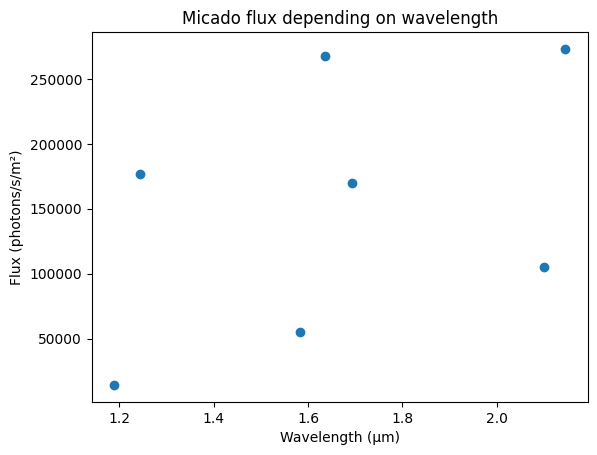

In [221]:
#micado flux depending on wavelength
lbd = [1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145]
lbd_broadband = [1.245, 1.635, 2.145]
planet_photon_flux_list = []

for i in range(len(lbd)):
    planet_photon_flux, planet_emission_per_pix, planet_global_transmission = get_micado_flux(flux_dir, 
                                                                             planet_flux, f'{lbd[i]:5.3f}', 
                                                                             frame_exp_time, telescope_surface, 
                                                                             airmass=airmass, pixel_scale=pixscale_in_mas)
    planet_photon_flux_list.append(planet_photon_flux)

plt.scatter(lbd, planet_photon_flux_list)
plt.title('Micado flux depending on wavelength')
plt.xlabel('Wavelength (µm)')
plt.ylabel('Flux (photons/s/m²)')
plt.show()

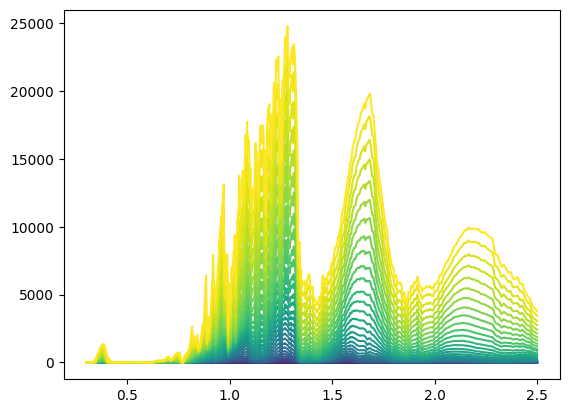

In [ ]:
#??? probably useless
metallicity = 0.32 #[0.32, 1.00, 3.16, 10.00, 31.62, 100.00]
temp = np.arange(200, 2000, 50)
logg = 3.5
CO =  0.50 #[0.10, 0.15, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
lbd = [1.190, 1.245, 1.582, 1.635, 1.693, 2.100, 2.145]
lbd_broadband = [1.245, 1.635, 2.145]
planet_photon_flux_list = []
planet_flux_list = []
lbd_contrast_index = []
#planet_flux_list_plot = []

n = len(temp)
colors = plt.cm.viridis(np.linspace(0,1,n))

#for j in range(len(CO)):
for k in range(len(temp)):
    planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp[k], logg, metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)
    planet_flux_list.append(planet_flux)

    plt.plot(spec_wave, planet_flux, color = colors[k])


    for i in range(len(spec_wave)):
        for j in range(len(lbd)):
            if spec_wave[i] == lbd[j] :

                lbd_contrast_index.append(i)
    
    # print('lbd contrast length =',len(lbd_contrast_index))
    # print('lbd contrast index =', lbd_contrast_index)

        #planet_photon_flux_list.append(planet_photon_flux)

        #print('list length = ', len(planet_flux_list))
    #print('lbd contrast length after =',len(lbd_contrast_index))

    # photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
    #                                                                 star_flux, f'{lbd_contrast_index[0]:5.3f}', 
    #                                                                 frame_exp_time, telescope_surface, 
    #                                                                 airmass=airmass, pixel_scale=pixscale_in_mas)
    planet_flux_list_plot = []
    for i in lbd_contrast_index :
        planet_flux_list_plot.append(planet_flux[i])
    #print('len planet_flux_list_plot = ', len(planet_flux_list_plot))

#     plt.scatter(lbd_contrast_index, planet_flux_list_plot, color = colors[k], marker = "o")
# plt.title('Planet photon flux')
# plt.xlabel('Wavelength (µm)')
# plt.ylabel('Flux (photons/s/m²)')
# plt.show()


# planet_flux_bb_list = []
# for i in range(len(lbd_broadband)):
#     planet_photon_flux_bb, planet_emission_per_pix, planet_global_transmission = get_micado_flux(flux_dir, 
#                                                                              planet_flux, f'{lbd[i]:5.3f}', 
#                                                                              frame_exp_time, telescope_surface, 
#                                                                              airmass=airmass, pixel_scale=pixscale_in_mas)
#     planet_flux_bb_list.append(planet_photon_flux_bb)
# mean = np.mean(planet_flux_bb_list)
# print(mean)

List of characterized temperatures :  [33300 31900 31400 29000 26000 24500 20600 18500 17000 16400 15700 14500
 14000 12300 10700 10400  9700  9300  8800  8600  8250  8100  7910  7760
  7590  7400  7220  7020  6820  6750  6670  6550  6350  6280  6180  6050
  5990  5930  5860  5770  5720  5680  5660  5600  5550  5480  5380  5270
  5170  5100  4830  4600  4440  4300  4100  3990  3930  3850  3770  3660
  3620  3560  3470  3430  3270  3210  3110  3060  2930  2810  2740  2680
  2630  2570  2420  2380  2350  2270  2160  2060]


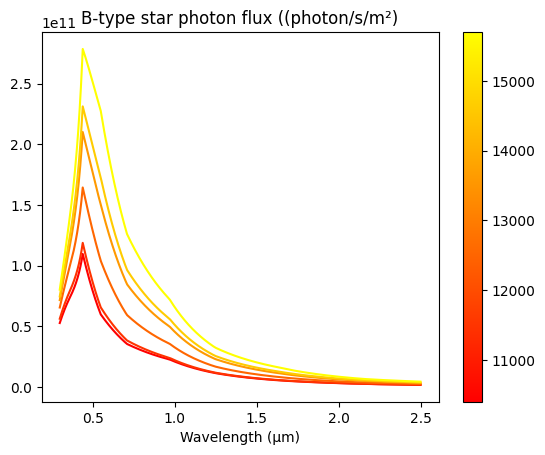

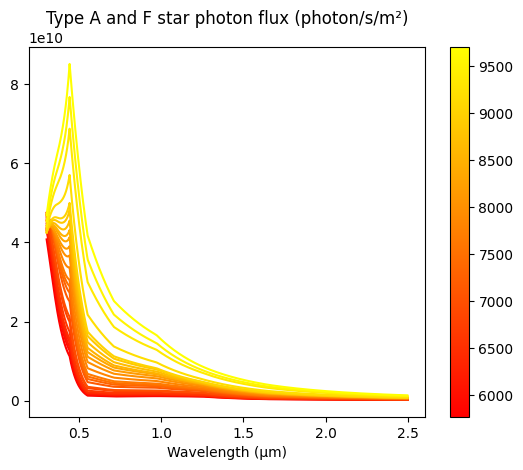

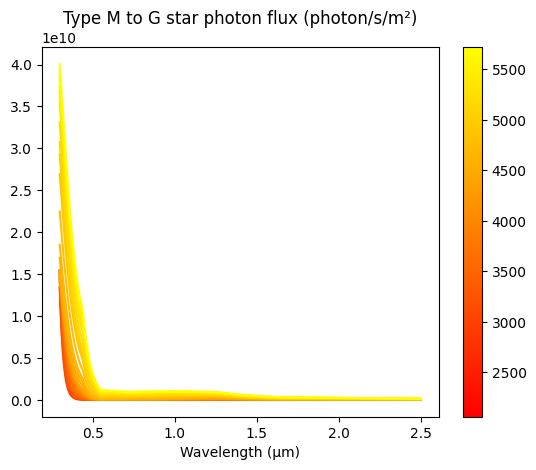

In [229]:
# Star fluxes

# importing the magnitudes for the V, J, H, K bands and physical parameters from the file
#data = np.genfromtxt('D:\FROM_RED\PecautMamajek2013_June2025.txt', dtype='str')
data = np.genfromtxt('C:/Users/Red Slottje/Documents/Doc_Rouge/PecautMamajek2013_June2025.txt', dtype='str')

U_B, M_V, M_J, J_H, M_K, =  pd.to_numeric(data[10:90,15], errors='coerce'), pd.to_numeric(data[10:90,7], errors='coerce'), pd.to_numeric(data[10:90,21], errors='coerce'), pd.to_numeric(data[10:90,19], errors='coerce'), pd.to_numeric(data[10:90:,22], errors='coerce')
logL, R_Rsun, masses, t_eff = pd.to_numeric(data[10:90,4], errors='coerce'), pd.to_numeric(data[10:90,6], errors='coerce'), pd.to_numeric(data[10:90,30], errors='coerce'), pd.to_numeric(data[10:90,1], errors='coerce')
M_H = M_J - J_H

print('List of characterized temperatures : ', t_eff)

# list of the central values of each spectral band (U, V, J, H, K respectively)
lbd = [0.299, 0.550, 1.2475 , 1.635, 2.150, 2.500]


############### Plot for B and O stars ################

temp_B_and_O = [15700, 14500, 14000, 12300, 10700 ,10400]

temp_B_and_O.sort()

n = len(temp_B_and_O)
colors = plt.cm.autumn(np.linspace(0,1,n))

c = np.array(temp_B_and_O)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

fig, ax = plt.subplots(dpi=100)

# retrieving the magnitudes in the interesting spectral bands at the given temperature (the file is a table with parameters as columns and stars as lines)
for i in range(len(temp_B_and_O)):
    for j in range(len(t_eff)):
        if t_eff[j] == temp_B_and_O[i] :
            star_mag = [U_B[j], M_V[j], M_H[j], M_J[j], M_K[j], M_K[j]]

# calculating star spectrum with the retrieved magnitudes
    wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd) 

# plotting the star's flux as a function of the wavelength
    plt.plot(wave_tr, star_flux, color = colors[i])
plt.colorbar(cmap, ax = ax)
plt.title('B-type star photon flux ((photon/s/m²)')
plt.xlabel('Wavelength (µm)')
plt.show()


################ Plot for A and F stars #################

temp_A_and_F = [9700,  9300 , 8800,  8600 , 8250, 8100,  7910 , 7760,
  7590,  7400 , 7220  ,7020 , 6820  ,6750 , 6670 , 6550, 6350,  6280,  6180,  6050,
  5990,  5930 , 5860  ,5770]

temp_A_and_F.sort()

n = len(temp_A_and_F)
colors = plt.cm.autumn(np.linspace(0,1,n))

c = np.array(temp_A_and_F)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

fig, ax = plt.subplots(dpi=100)

# retrieving the magnitudes in the interesting spectral bands at the given temperature (the file is a table with parameters as columns and stars as lines)
for i in range(len(temp_A_and_F)):
    for j in range(len(t_eff)):
        if t_eff[j] == temp_A_and_F[i] :
            star_mag = [U_B[j], M_V[j], M_H[j], M_J[j], M_K[j], M_K[j]]

# calculating star spectrum with the retrieved magnitudes
    wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd) 

# plotting the star's flux as a function of the wavelength
    plt.plot(wave_tr, star_flux, color = colors[i])

plt.colorbar(cmap, ax = ax)
plt.title('Type A and F star photon flux (photon/s/m²)')
plt.xlabel('Wavelength (µm)')
plt.show()


############### Plot for G and under stars ##################

temp_under_G = [5720 , 5680,  5660,  5600,  5550,  5480,  5380,  5270,
  5170,  5100,  4830,  4600 , 4440,  4300,  4100,  3990 , 3930,  3850,  3770,  3660,
  3620,  3560,  3470,  3430,  3270 , 3210 , 3110,  3060 , 2930 , 2810 , 2740,  2680,
  2630,  2570,  2420,  2380 , 2350  ,2270 , 2160,  2060]

temp_under_G.sort()

n = len(temp_under_G)
colors = plt.cm.autumn(np.linspace(0,1,n))

# setting up the colorbar
c = np.array(temp_under_G)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.autumn)
cmap.set_array([])

fig, ax = plt.subplots(dpi=100)
# retrieving the magnitudes in the interesting spectral bands at the given temperature (the file is a table with parameters as columns and stars as lines)
for i in range(len(temp_under_G)):
    
    for j in range(len(t_eff)):
        if t_eff[j] == temp_under_G[i] :
            star_mag = [U_B[j], M_V[j], M_H[j], M_J[j], M_K[j], M_K[j]]

# calculating star spectrum with the retrieved magnitudes
    wave_tr, star_flux = get_star_spectrum(flux_dir, star_mag, lbd) 

# plotting the star's flux as a function of the wavelength
    plt.plot(wave_tr, star_flux, color = colors[i])
plt.colorbar(cmap, ax = ax)
plt.title('Type M to G star photon flux (photon/s/m²)')
plt.xlabel('Wavelength (µm)')
plt.show()

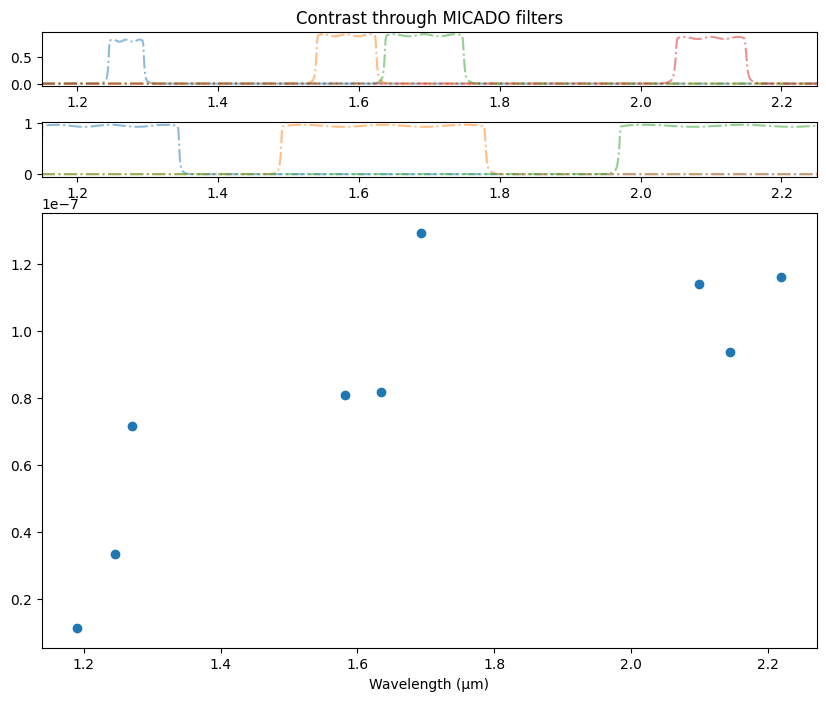

In [ ]:
# contrast 
metallicity = 3.16
CO = 0.15
temp = 800
logg = 3.5
#lbd = [1.2475 , 1.635, 2.145]
lbd = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220, 1.245, 1.635, 2.145]

photon_flux_list = []
planet_photon_flux_list = []
contrast = []

planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity, CO, dist_pc, r_pl, flux_dir=flux_dir)
planet_flux_list.append(planet_flux)

# extracting the filter data from the input files
tr_filter0  = fits.getdata(flux_dir+'Transmission_filter_J1J2H1H2K1K2_v2020.fits')
tr_filter1  = fits.getdata(flux_dir+'Transmission_filter_JHK.fits')
wave_tr     = fits.getdata(flux_dir+'Wavelength_for_emission_transmission_in_micrometer.fits')
    
wave_step   = np.mean(np.diff(wave_tr))

#defining the bands from the filter 
Jshort = tr_filter0[0,:] #lbd = 1.190
Jlong = tr_filter0[1,:] #lbd = 1.270
Hshort = tr_filter0[2,:] #lbd = 1.582
Hlong = tr_filter0[3,:] #lbd = 1.693
Kmid = tr_filter0[4,:] # lbd = 2.100
Jbroad = tr_filter1[0,:] #lbd = 1.245
Hbroad = tr_filter1[1,:] #lbd = 1.635
Kbroad = tr_filter1[2,:] #lbd = 2.145
    
tr_filter = [Jlong, Hshort, Hlong, Kmid]
tr_filter_broad = [Jbroad, Hbroad, Kbroad]

# get flux of the correct wavelengths        
for i in range(len(lbd)):
  
    photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
    photon_flux_list.append(photon_flux)

    planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
    planet_photon_flux_list.append(planet_photon_flux)
    contrast.append(planet_photon_flux/photon_flux)

fig1, axs = plt.subplots(3,1, height_ratios = [1, 1, 8], figsize = (10, 8))
for i in range(len(tr_filter)):
    axs[0].set_title('Contrast through MICADO filters')
    axs[0].plot(wave_tr, tr_filter[i], '-.', label=f'Filter ({tr_filter}um)', alpha=.5)
    axs[0].set_xlim(1.150, 2.250)
for j in range(len(tr_filter_broad)):
    axs[1].plot(wave_tr, tr_filter_broad[j], '-.', label=f'Filter ({tr_filter_broad}um)', alpha=.5)
    axs[1].set_xlim(1.150, 2.250)


axs[2].scatter(lbd, contrast)
#plt.title('Contrast through MICADO filters')
plt.xlabel('Wavelength (µm)')
plt.show()


In [ ]:
hdul = fits.open("physical_planet_parameters_storage.fits")
hdu = hdul[1]
metallicity = hdu.data
temp = hdul[2].data
print(metallicity)


[(  0.32,) (  1.  ,) (  3.16,) ( 10.  ,) ( 31.62,) (100.  ,)]


ValueError: x and y must be the same size

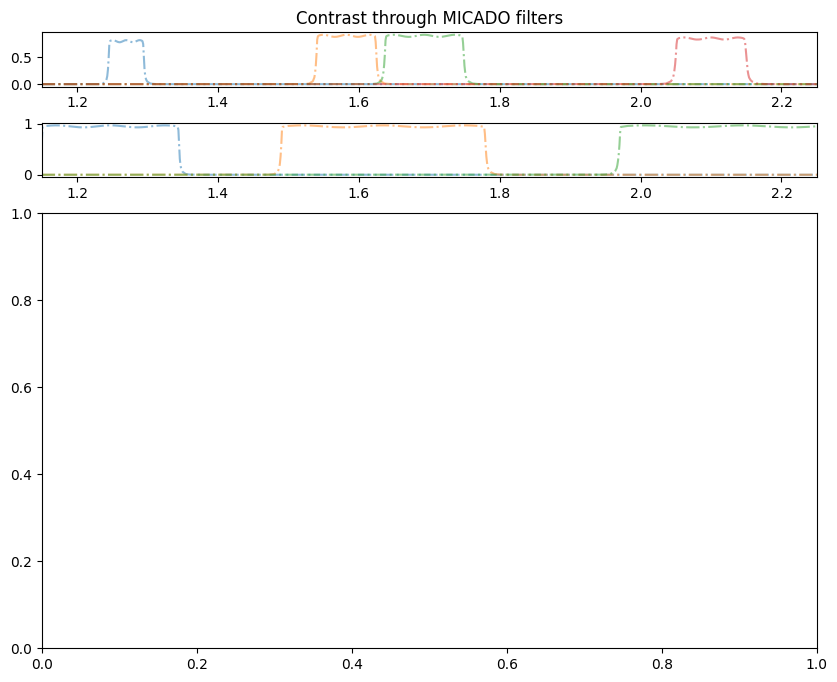

In [ ]:
# contrast but iterating
#metallicity = 3.16
CO = 0.15
temp = 800
logg = 3.5
#lbd = [1.2475 , 1.635, 2.145]
lbd = [1.190, 1.270, 1.582, 1.693, 2.100, 2.220, 1.245, 1.635, 2.145]
metallicity = [0.32, 1.00, 3.16, 10.00, 31.62, 100.00]

n = len(metallicity)
colors = plt.cm.autumn(np.linspace(0,1,n))

photon_flux_list = []
planet_photon_flux_list = []
contrast = []

# get the spectrum from the file
# for i in range(len(metallicity)):
#     planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity[i], CO, dist_pc, r_pl, flux_dir=flux_dir)
#     planet_flux_list.append(planet_flux)

# extracting the filter data from the input files
tr_filter0  = fits.getdata(flux_dir+'Transmission_filter_J1J2H1H2K1K2_v2020.fits')
tr_filter1  = fits.getdata(flux_dir+'Transmission_filter_JHK.fits')
wave_tr     = fits.getdata(flux_dir+'Wavelength_for_emission_transmission_in_micrometer.fits')
    
wave_step   = np.mean(np.diff(wave_tr))

#defining the bands from the filter 
Jshort = tr_filter0[0,:] #lbd = 1.190
Jlong = tr_filter0[1,:] #lbd = 1.270
Hshort = tr_filter0[2,:] #lbd = 1.582
Hlong = tr_filter0[3,:] #lbd = 1.693
Kmid = tr_filter0[4,:] # lbd = 2.100
Jbroad = tr_filter1[0,:] #lbd = 1.245
Hbroad = tr_filter1[1,:] #lbd = 1.635
Kbroad = tr_filter1[2,:] #lbd = 2.145
    
tr_filter = [Jlong, Hshort, Hlong, Kmid]
tr_filter_broad = [Jbroad, Hbroad, Kbroad]

# get flux of the correct wavelengths        
for i in range(len(lbd)):
  
    photon_flux, emission_per_pix, global_transmission = get_micado_flux(flux_dir, 
                                                                    star_flux, f'{lbd[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
    photon_flux_list.append(photon_flux)

    for k in range(len(metallicity)) :
        planet_flux, spec_wave = get_planet_spectrum(spec_dir, temp, logg, metallicity[k], CO, dist_pc, r_pl, flux_dir=flux_dir)

        #plt.plot(spec_wave,planet_flux, color = colors[k])

        planet_photon_flux, pl_emission_per_pix, pl_global_transmission = get_micado_flux(flux_dir, 
                                                                    planet_flux, f'{lbd[i]:5.3f}', 
                                                                    frame_exp_time, telescope_surface, 
                                                                    airmass=airmass, pixel_scale=pixscale_in_mas)
        planet_photon_flux_list.append(planet_photon_flux)
        contrast.append(planet_photon_flux/photon_flux)

fig1, axs = plt.subplots(3,1, height_ratios = [1, 1, 8], figsize = (10, 8))
for i in range(len(tr_filter)):
    axs[0].set_title('Contrast through MICADO filters')
    axs[0].plot(wave_tr, tr_filter[i], '-.', label=f'Filter ({tr_filter}um)', alpha=.5)
    axs[0].set_xlim(1.150, 2.250)
for j in range(len(tr_filter_broad)):
    axs[1].plot(wave_tr, tr_filter_broad[j], '-.', label=f'Filter ({tr_filter_broad}um)', alpha=.5)
    axs[1].set_xlim(1.150, 2.250)


axs[2].scatter(lbd, contrast)
#plt.title('Contrast through MICADO filters')
plt.xlabel('Wavelength (µm)')
plt.show()
